In [12]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('adult_with_headers (1).csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#Data Exploration

Explore the dataset by checking its shape, information, summary statistics, data types, and missing values.

In [14]:
print("Shape:", df.shape)

df.info()

df.describe()

df.dtypes

df.isnull().sum()

Shape: (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

#Handle Missing Values

Replace '?' values with NaN and fill missing categorical values using the mode.

In [15]:
df.replace(" ?", np.nan, inplace=True)

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

C:\Users\gurra\AppData\Local\Temp\ipykernel_23444\1863850463.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Apply Standard Scaling

Standard Scaling transforms numerical features so that they have a mean of 0 and a standard deviation of 1.

It is commonly used with Logistic Regression, SVM, PCA, and KNN.

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

standard_scaler = StandardScaler()

df_standard = df.copy()

df_standard[numerical_columns] = standard_scaler.fit_transform(df_standard[numerical_columns])

df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


Apply Min-Max Scaling

Min-Max Scaling transforms numerical values into a range between 0 and 1.

It is mainly used for Neural Networks and Deep Learning algorithms.

In [18]:
minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[numerical_columns] = minmax_scaler.fit_transform(df_minmax[numerical_columns])

df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


## Scenarios Where Each Scaling Technique is Preferred and Why

### Standard Scaling

**Preferred Scenarios:**
- When the numerical data is approximately normally distributed.
- When using machine learning algorithms such as Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Principal Component Analysis (PCA).

**Why?**
- Standard Scaling transforms the data to have a mean of 0 and a standard deviation of 1.
- It ensures that all features contribute equally to the model.
- It improves the performance and convergence of many machine learning algorithms.

---

### Min-Max Scaling

**Preferred Scenarios:**
- When the data does not follow a normal distribution.
- When features need to be scaled to a fixed range (usually 0 to 1).
- Commonly used in Neural Networks, Deep Learning models, and image processing applications.

**Why?**
- Min-Max Scaling rescales all feature values to the range of 0 to 1.
- It preserves the original distribution of the data while maintaining the relationships between values.
- It is suitable for algorithms that require bounded input values.

---

### Conclusion

Standard Scaling is preferred for algorithms such as Logistic Regression, SVM, KNN, and PCA because these algorithms perform better when features have a mean of 0 and a standard deviation of 1. Min-Max Scaling is preferred for Neural Networks and Deep Learning models because it scales all feature values to a fixed range (0–1), resulting in faster and more stable model training.

 One-Hot Encoding

Apply One-Hot Encoding to categorical variables having fewer than five unique categories.

In [19]:
for col in categorical_columns:
    print(col, df[col].nunique())

workclass 8
education 16
marital_status 7
occupation 14
relationship 6
race 5
sex 2
native_country 41
income 2


In [20]:
onehot_columns = ['sex', 'income']

df_onehot = pd.get_dummies(df,
                           columns=onehot_columns,
                           drop_first=True)

df_onehot.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,True,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,False,False


#Label Encoding

Apply Label Encoding to categorical variables having more than five unique categories.

In [29]:
label = LabelEncoder()

label_columns = ['workclass',
                 'education',
                 'marital_status',
                 'occupation',
                 'relationship',
                 'race',
                 'native_country']

for col in label_columns:
    df[col] = label.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,age_hours,capital_gain_log
0,39,6,77516,9,13,4,0,1,4,Male,2174,0,40,38,<=50K,2174,1560,7.684784
1,50,5,83311,9,13,2,3,0,4,Male,0,0,13,38,<=50K,0,650,0.000000
2,38,3,215646,11,9,0,5,1,4,Male,0,0,40,38,<=50K,0,1520,0.000000
3,53,3,234721,1,7,2,5,0,2,Male,0,0,40,38,<=50K,0,2120,0.000000
4,28,3,338409,9,13,2,9,5,2,Female,0,0,40,4,<=50K,0,1120,0.000000


In [30]:
df.head()
df.info()
df.describe()
df.isnull().sum()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32561 non-null  int64  
 1   workclass         32561 non-null  int64  
 2   fnlwgt            32561 non-null  int64  
 3   education         32561 non-null  int64  
 4   education_num     32561 non-null  int64  
 5   marital_status    32561 non-null  int64  
 6   occupation        32561 non-null  int64  
 7   relationship      32561 non-null  int64  
 8   race              32561 non-null  int64  
 9   sex               32561 non-null  object 
 10  capital_gain      32561 non-null  int64  
 11  capital_loss      32561 non-null  int64  
 12  hours_per_week    32561 non-null  int64  
 13  native_country    32561 non-null  int64  
 14  income            32561 non-null  object 
 15  capital_total     32561 non-null  int64  
 16  age_hours         32561 non-null  int64 

age                   int64
workclass             int64
fnlwgt                int64
education             int64
education_num         int64
marital_status        int64
occupation            int64
relationship          int64
race                  int64
sex                  object
capital_gain          int64
capital_loss          int64
hours_per_week        int64
native_country        int64
income               object
capital_total         int64
age_hours             int64
capital_gain_log    float64
dtype: object

 Advantages and Disadvantages

## One-Hot Encoding

Advantages
- Prevents ordinal relationships
- Improves model accuracy

Disadvantages
- Creates many columns
- Requires more memory

## Label Encoding

Advantages
- Simple and memory efficient
- Faster preprocessing

Disadvantages
- Introduces ordinal relationships
- May affect some machine learning models

#Feature Engineering

Create new meaningful features that improve model performance.

In [24]:
df["capital_total"] = df["capital_gain"] - df["capital_loss"]

df["age_hours"] = df["age"] * df["hours_per_week"]

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,age_hours
0,39,6,77516,9,13,4,0,1,4,Male,2174,0,40,38,<=50K,2174,1560
1,50,5,83311,9,13,2,3,0,4,Male,0,0,13,38,<=50K,0,650
2,38,3,215646,11,9,0,5,1,4,Male,0,0,40,38,<=50K,0,1520
3,53,3,234721,1,7,2,5,0,2,Male,0,0,40,38,<=50K,0,2120
4,28,3,338409,9,13,2,9,5,2,Female,0,0,40,4,<=50K,0,1120


#  Log Transformation

Capital Gain is highly skewed.

Log Transformation reduces skewness and improves model performance.

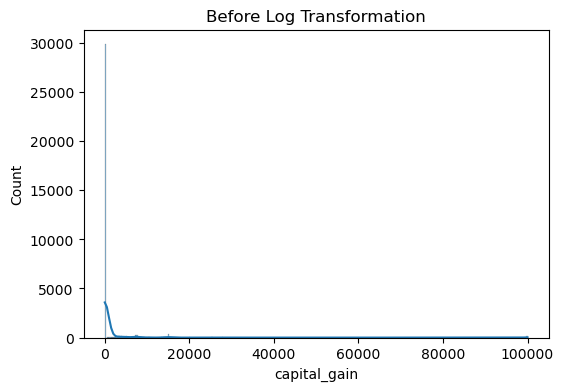

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df["capital_gain"], kde=True)
plt.title("Before Log Transformation")
plt.show()

In [26]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])

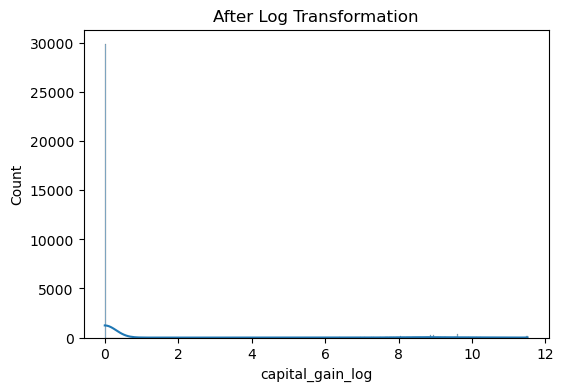

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df["capital_gain_log"], kde=True)
plt.title("After Log Transformation")
plt.show()

#Final Dataset

Display the final processed dataset after completing all preprocessing and feature engineering steps.

In [28]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32561 non-null  int64  
 1   workclass         32561 non-null  int64  
 2   fnlwgt            32561 non-null  int64  
 3   education         32561 non-null  int64  
 4   education_num     32561 non-null  int64  
 5   marital_status    32561 non-null  int64  
 6   occupation        32561 non-null  int64  
 7   relationship      32561 non-null  int64  
 8   race              32561 non-null  int64  
 9   sex               32561 non-null  object 
 10  capital_gain      32561 non-null  int64  
 11  capital_loss      32561 non-null  int64  
 12  hours_per_week    32561 non-null  int64  
 13  native_country    32561 non-null  int64  
 14  income            32561 non-null  object 
 15  capital_total     32561 non-null  int64  
 16  age_hours         32561 non-null  int64 

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,capital_total,age_hours,capital_gain_log
count,32561.000000,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,3.094438,1.897784e+05,10.298210,10.080679,2.611836,6.138755,1.446362,3.665858,1077.648844,87.303830,40.437456,36.417155,990.345014,1571.723411,0.734621
std,13.640433,1.107194,1.055500e+05,3.870264,2.572720,1.506222,3.972708,1.606771,0.848806,7385.292085,402.960219,12.347429,6.056047,7408.986951,740.732449,2.454738
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-4356.000000,21.000000,0.000000
25%,28.000000,3.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,40.000000,38.000000,0.000000,1050.000000,0.000000
50%,37.000000,3.000000,1.783560e+05,11.000000,10.000000,2.000000,6.000000,1.000000,4.000000,0.000000,0.000000,40.000000,38.000000,0.000000,1520.000000,0.000000
75%,48.000000,3.000000,2.370510e+05,12.000000,12.000000,4.000000,9.000000,3.000000,4.000000,0.000000,0.000000,45.000000,38.000000,0.000000,2016.000000,0.000000
max,90.000000,7.000000,1.484705e+06,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,99999.000000,4356.000000,99.000000,40.000000,99999.000000,8910.000000,11.512925


# Conclusion

The Adult Income dataset was successfully preprocessed by handling missing values, applying Standard Scaling and Min-Max Scaling, performing One-Hot Encoding and Label Encoding, creating new features, and applying Log Transformation. These preprocessing techniques improve data quality and prepare the dataset for machine learning model development.